In [1]:
import numpy as np
import networkx as nx
from collections import defaultdict

from QHyper.converter import Converter
from QHyper.constraint import Polynomial

from dwave.system import DWaveSampler
from dimod import BinaryQuadraticModel

from QHyper.problems.community_detection import CommunityDetectionProblem, Network

In [2]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

In [3]:
from Qommunity.samplers.hierarchical.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher


gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)
res = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

comms = res.communities[0]
div_tree = res.division_tree[0]
div_mods = res.division_modularities[0]

100%|██████████| 1/1 [00:00<00:00,  2.50it/s]


In [4]:
division_tree = div_tree
communities = comms
division_modularities = div_mods

In [5]:
class Node:
    def __init__(self, id, values, left=None, right=None, parent=None):
        self.id = id
        self.values = values
        self.left = left
        self.right = right
        self.parent = parent

    def __str__(self):
        return f"Node(id={self.id}, values={self.values})"
    
    def __repr__(self):
        return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
    def __eq__(self, node):
        if not isinstance(node, Node):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

class Tree:
    def __init__(self, root):
        self.root = root
        self.nodes = [root]

In [6]:
def recover_ordering(division_tree):
    root = Node(id=hash(tuple(G.nodes)), values=list(G.nodes), left=None, right=None, parent=None)
    nodes = {}

    for level in reversed(range(len(division_tree))):
        level_clustering = division_tree[level]

        if level == len(division_tree) - 1:
            for cluster in level_clustering:
                leaf_node = Node(id=hash(tuple(cluster)), values=cluster, left=None, right=None, parent=None)
                nodes[leaf_node.id] = leaf_node
        else:
            subsequent_clusters = division_tree[level + 1]
            subclusters = {}

            for subsequent_cluster in subsequent_clusters: # children clusters
                for cluster in level_clustering: # parent clusters
                    if set(subsequent_cluster).issubset(set(cluster)): # if subsequent cluster is child of the parent
                        key_clus = hash(tuple(cluster))
                        
                        if key_clus not in subclusters.keys():
                            subclusters[key_clus] = subsequent_cluster
                        else:
                            subclusters[key_clus] = (
                                subclusters.get(key_clus),
                                subsequent_cluster,
                            )                    

            for cluster in level_clustering:
                key_clus = hash(tuple(cluster))

                if type(subclusters[key_clus]) == tuple:
                    c0, c1 = subclusters[key_clus]
                    key1, key2 = hash(tuple(c0)), hash(tuple(c1))

                    child_node_1 = nodes[key1]
                    child_node_2 = nodes[key2]

                    parent_node = Node(id=key_clus, values=cluster, left=child_node_1, right=child_node_2, parent=None)
                    nodes[parent_node.id] = parent_node

                    child_node_1.parent = parent_node
                    child_node_2.parent = parent_node
                    
                    # Sanity checks
                    assert child_node_1.parent == parent_node
                    assert child_node_2.parent == parent_node


                # only one subcommunity - list
                elif type(subclusters[key_clus]) == list and level != 0:
                    pass # Nothing to do in here

    root = nodes[root.id]
    return nodes, root

In [7]:
nodes, root = recover_ordering(div_tree)

In [16]:
nodes

{4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 508968978265049823: Node(values=[0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], left=None, right=None),
 9094344604165242636: Node(values=[6, 90, 98], left=None, right=None),
 7673536023032186979: Node(values=[34, 52, 94, 99], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 -2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 -1198255070108046162: Node(values=[12, 17, 35, 36, 40, 65, 67, 74, 79, 92], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -4103333047921192956: Node(values=[19, 38, 41, 46, 49, 53, 76, 78, 80, 83], left=None, right=None),
 -8474

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = div_mods[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    # pr_id = comm_hash_to_pr_id[hash(tuple(values))]
    # chain_strength = pr_id_to_chain_strength[pr_id]
    # chain_strength = comm_hash_to_ch_str[hash(tuple(values))]
    chain_strength = 0.93

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level, chain_strength=chain_strength)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)

    
def center_parents(G, pos):
    """Center parents above children."""
    for n, data in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True):
        children = list(G.successors(n))
        if len(children) == 2:
            x1, _ = pos[children[0]]
            x2, _ = pos[children[1]]
            _, y = pos[n]
            pos[n] = ((x1 + x2)/2, y)
    return pos


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    center_parents(G, pos)

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']
        chain_strength = node_data['chain_strength']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {chain_strength}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


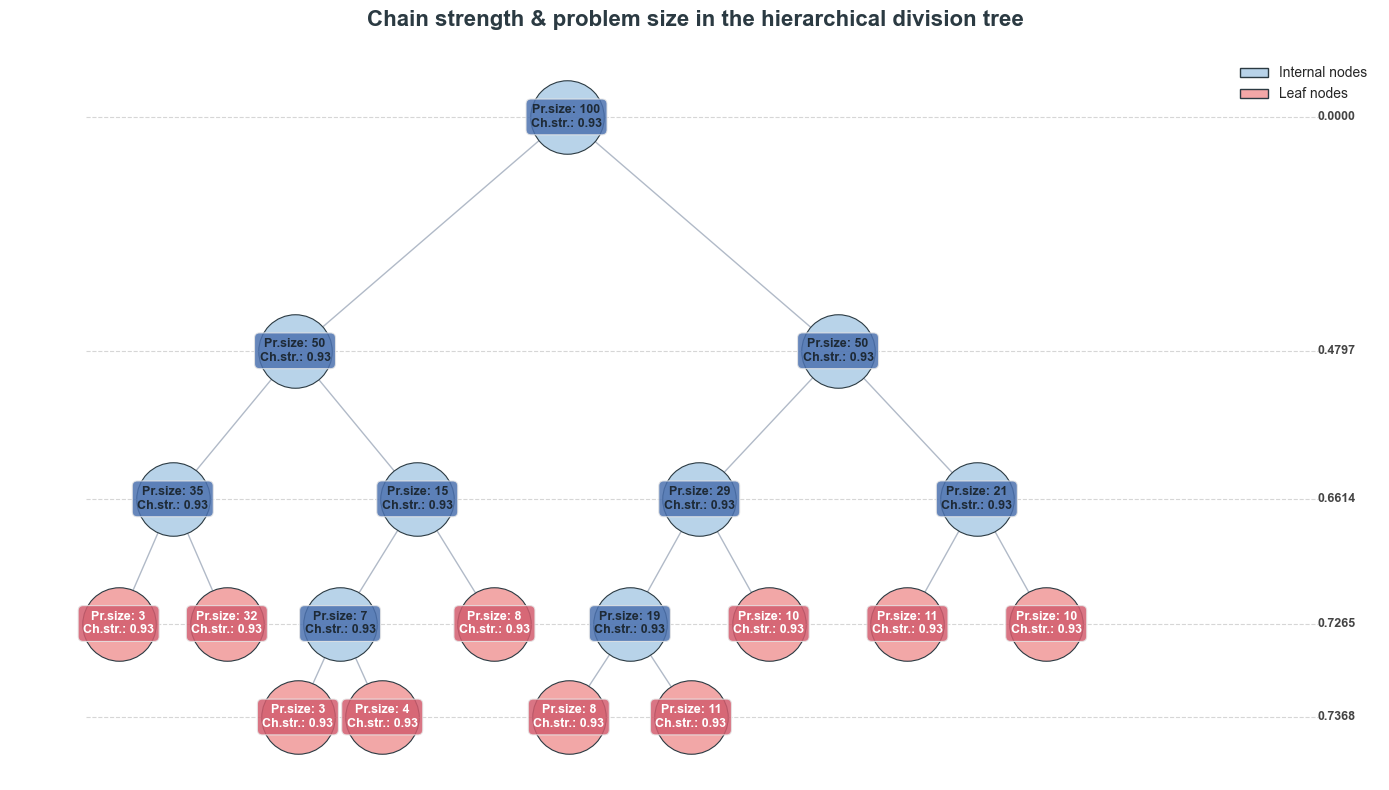

In [15]:
plot_tree(root)

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_tree_with_modularity_axis(root):
    """Original modern tree layout with modularity axis annotations."""
    G = nx.DiGraph()
    build_graph(G, root)  # your existing build_graph function
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    fig, ax = plt.subplots(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Node colors
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    node_size = 2800

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=internals, node_color=internal_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=leaves, node_color=leaf_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=False, edge_color="#7d8ca3", width=1.0, alpha=0.6, ax=ax)

    # Draw node labels
    for node, (x, y) in pos.items():
        data = G.nodes[node]
        # mod_value = data['mod_value']
        values = data['values']
        text_color = "black" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label = f"{len(values)}"
        lvl = data["level"]
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        n_nodes = len(nodes_at_level)
        if n_nodes in [1]:
            max_items_per_line = len(values) // 2
        elif n_nodes in [2]:
            max_items_per_line = 10
        else:
            max_items_per_line = 4

        label = divide_label(values, max_items_per_line)
        label = "[" + label + "]"     

        # plt.text(x, y, label,
        #          ha="center", va="center",
        #          fontsize=9, color=text_color, fontweight=font_weight,
        #          wrap=True, zorder=4)
        plt.text(x, y, label,
                 ha="center", va="center",
                 fontsize=9, color=text_color, fontweight=font_weight,
                 wrap=True, zorder=4)

    # --- Add modularity axis on the right ---
    # Get all unique levels and modularities
    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            mean_x = sum(pos[n][0] for n in nodes_at_level) / len(nodes_at_level)
            ax.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            ax.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
    
    y_coords_end = max(pos[n][1] for n in nodes_at_level)
    nodes_at_0 = [n for n, d in G.nodes(data=True) if d['level'] == 0]
    y_coords_start = min([pos[n][1] for n in nodes_at_0])
    # ax.vlines(x=xmax+dx / 2, ymin=y_coords_start, ymax=y_coords_end,  # extend slightly above/below
    #           colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)

    ax.set_title("Hierarchcial Division Tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


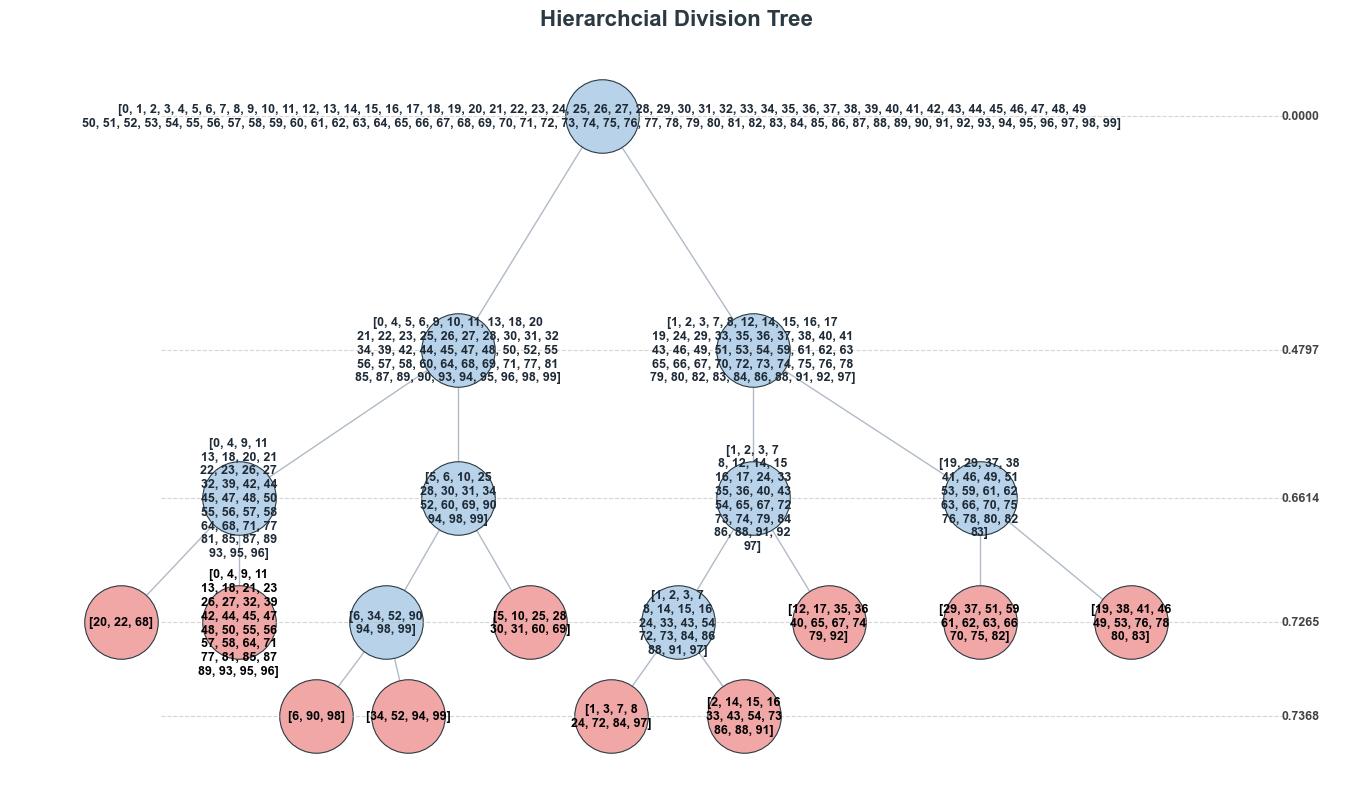

In [21]:
plot_tree_with_modularity_axis(root)